<a href="https://colab.research.google.com/github/Ramjeet-Dixit/IITM-AIML-Rdixit/blob/main/yolo_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# YOLO Object Detection Demo (YOLOv8 Pre-trained)

In this demo, we will:
1. Install and load the Ultralytics YOLO library.
2. Load a pre-trained YOLOv8 model.
3. Run object detection on sample images.
4. Visualize predictions with bounding boxes and class labels.


In [ ]:
# Install Ultralytics
!pip install ultralytics --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 46.6 MB/s eta 0:00:00


In [ ]:
# Import YOLO
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2 #open cv

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Load Pre-trained YOLOv8 Model
We use YOLOv8s (small) trained on COCO dataset with 80 classes.


In [ ]:
# Load YOLOv8 small model
model = YOLO("yolov8s.pt")


## Run Inference on Sample Images
We can try:
- A street scene (cars, people, bikes)
- An indoor image (objects like chair, laptop, bottle)


In [ ]:
# Download a test image (you can replace with local image paths)
!wget -q https://ultralytics.com/images/bus.jpg -O bus.jpg
!wget -q https://ultralytics.com/images/zidane.jpg -O zidane.jpg



In [ ]:

# Run inference
results1 = model("bus.jpg")
#results2 = model("zidane.jpg")


image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 693.4ms
Speed: 21.0ms preprocess, 693.4ms inference, 46.0ms postprocess per image at shape (1, 3, 640, 480)


## Visualize Predictions
YOLO automatically saves annotated images in `runs/detect/predict`.


In [ ]:
plt.subplot(1, 2, 2)

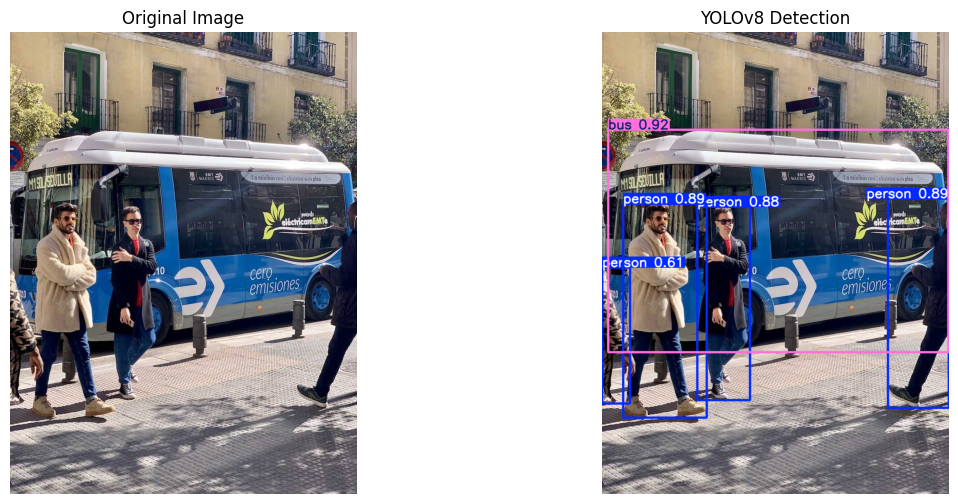

In [ ]:
import matplotlib.pyplot as plt
import cv2


# Extract original and annotated images
orig_img = results1[0].orig_img              # original image (BGR format)
annotated_img = results1[0].plot()           # YOLO’s annotated output (BGR format)

# Convert BGR → RGB for matplotlib
orig_img_rgb = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

# Plot side by side
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(orig_img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(annotated_img_rgb)
plt.title("YOLOv8 Detection")
plt.axis("off")

plt.show()


In [ ]:

# Run inference
results2 = model("zidane.jpg")
#results2 = model("zidane.jpg")


image 1/1 /content/zidane.jpg: 384x640 2 persons, 1 tie, 408.8ms
Speed: 3.8ms preprocess, 408.8ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


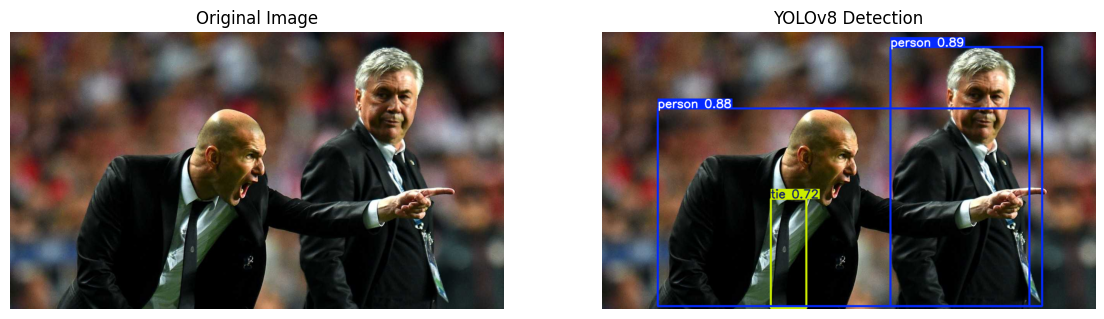

In [ ]:
import matplotlib.pyplot as plt
import cv2


# Extract original and annotated images
orig_img = results2[0].orig_img              # original image (BGR format)
annotated_img = results2[0].plot()           # YOLO’s annotated output (BGR format)

# Convert BGR → RGB for matplotlib
orig_img_rgb = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

# Plot side by side
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(orig_img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(annotated_img_rgb)
plt.title("YOLOv8 Detection")
plt.axis("off")

plt.show()


# Key Takeaways
- YOLO (You Only Look Once) performs **real-time object detection**.
- The model predicts **both class labels and bounding boxes**.
- Pre-trained YOLO models can be directly used for inference.
- For custom tasks (like detecting specific objects), YOLO can be **fine-tuned** on your dataset.


## Optional: Object Detection on live video feed
- It will not work in our lab, works only locally

In [ ]:
# Install Ultralytics YOLO
!pip install ultralytics opencv-python --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 11.9 MB/s eta 0:00:00


In [ ]:
import cv2
from ultralytics import YOLO

# Load a pre-trained YOLOv8 model (small version for speed)
model = YOLO("yolov8s.pt")

# Open webcam (0 = default camera, change index if needed)
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()

while True:
    # Read frame from webcam
    ret, frame = cap.read()
    if not ret:
        break

    # Run YOLO inference
    results = model(frame, verbose=False)

    # Annotated frame (YOLO returns list of results, take first)
    annotated_frame = results[0].plot()

    # Show the frame
    cv2.imshow("YOLOv8 Webcam Detection", annotated_frame)

    # Break on 'q' key
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release resources
cap.release()
cv2.destroyAllWindows()


Error: Could not open webcam.
